In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Code to download the dataset which has 70000 Instances  

In [ ]:
# Step 1: Install required libraries (only once per Colab runtime)
!pip install tensorflow scikit-learn matplotlib pandas


In [ ]:
# Step 2: Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers


In [ ]:
# Step 1: Import libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Step 2: Load your uploaded MNIST file
data = np.load('mnist.npz')   # File you uploaded in left panel

X_train_full = data['x_train']
y_train_full = data['y_train']
X_test_full = data['x_test']
y_test_full = data['y_test']

print("Train:", X_train_full.shape, "Test:", X_test_full.shape)


Train: (60000, 28, 28) Test: (10000, 28, 28)


In [ ]:
# Combine training and testing for unified splitting
X_full = np.concatenate([X_train_full, X_test_full], axis=0)
y_full = np.concatenate([y_train_full, y_test_full], axis=0)

# Normalize and reshape
X_full = X_full.astype('float32') / 255.0  # MNIST pixel range 0–255
X_full = np.expand_dims(X_full, -1)        # (n, 28, 28, 1)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_full_oh = encoder.fit_transform(y_full.reshape(-1, 1))

# Split 70/15/15
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_full, y_full_oh, test_size=0.15, random_state=42, stratify=y_full
)
val_fraction = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_fraction, random_state=42,
    stratify=np.argmax(y_train_val, axis=1)
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (49000, 28, 28, 1) Val: (10500, 28, 28, 1) Test: (10500, 28, 28, 1)


Part **B**  
Compare the network with state-of-the-art networks


In [ ]:
# === Q14: Load & configure ResNet50 and DenseNet121 for fine-tuning on MNIST ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import resnet, densenet
import numpy as np

SEED = 42
BATCH = 64
IMG_SIZE = 224    # Typical for ImageNet backbones
NUM_CLASSES = y_train.shape[1]  # From your Part-1 one-hot labels

# ----- Dataset builders: grayscale->RGB, resize, scale to [0,255], model-specific preprocess_input -----
def make_ds_from_arrays(X, Y, preprocess_fn, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)

    def _prep(x, y):
        x = tf.image.grayscale_to_rgb(x)                              # (28,28,1) -> (28,28,3)
        x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE), method="bilinear")
        x = x * 255.0                                                # required before preprocess_input
        x = preprocess_fn(x)                                         # ResNet/DenseNet-specific
        return x, y

    return ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)\
             .batch(BATCH)\
             .prefetch(tf.data.AUTOTUNE)

# ----- Model builders: load pretrained backbone, add GAP->Dropout->Dense(K) -----
def build_model(arch: str, num_classes: int):
    if arch == "resnet":
        base = resnet.ResNet50(weights="imagenet", include_top=False,
                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = resnet.preprocess_input
        trainable_from = -30  # unfreeze top ~30 layers for fine-tuning
    elif arch == "densenet":
        base = densenet.DenseNet121(weights="imagenet", include_top=False,
                                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = densenet.preprocess_input
        trainable_from = -40
    else:
        raise ValueError("arch must be 'resnet' or 'densenet'")

    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)                  # keep batchnorms in inference mode while frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=f"{arch}_finetune")

    return model, base, preprocess, trainable_from

# ----- Compile for Stage-1 (feature extractor; backbone frozen) -----
def compile_head_training(model, base, lr=1e-3):
    base.trainable = False
    try:
        opt = keras.optimizers.AdamW(learning_rate=lr)
    except Exception:
        opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

# ----- Prepare for Stage-2 (fine-tuning; unfreeze top layers, low LR) -----
def prepare_for_finetune(model, base, trainable_from, lr=1e-4):
    base.trainable = True
    # Keep earlier layers frozen; unfreeze only the top block(s)
    for layer in base.layers[:trainable_from]:
        layer.trainable = False
    try:
        opt = keras.optimizers.AdamW(learning_rate=lr)
    except Exception:
        opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

# ===== Build models and datasets (NO TRAINING yet — that’s Q15) =====
# ResNet50
resnet_model, resnet_base, resnet_preprocess, resnet_from = build_model("resnet", NUM_CLASSES)
compile_head_training(resnet_model, resnet_base, lr=1e-3)         # Stage-1 setup
resnet_train = make_ds_from_arrays(X_train, y_train, resnet_preprocess, training=True)
resnet_val   = make_ds_from_arrays(X_val,   y_val,   resnet_preprocess, training=False)
resnet_test  = make_ds_from_arrays(X_test,  y_test,  resnet_preprocess, training=False)

# Optional sanity check (forward pass, no training):
xb, yb = next(iter(resnet_train))
_ = resnet_model.predict(xb[:4], verbose=0)
print("ResNet50 forward pass OK:", _.shape)

# Prepare for fine-tuning (we'll actually train in Q15)
prepare_for_finetune(resnet_model, resnet_base, trainable_from=resnet_from, lr=1e-4)

# DenseNet121
densenet_model, densenet_base, densenet_preprocess, densenet_from = build_model("densenet", NUM_CLASSES)
compile_head_training(densenet_model, densenet_base, lr=1e-3)     # Stage-1 setup
dns_train = make_ds_from_arrays(X_train, y_train, densenet_preprocess, training=True)
dns_val   = make_ds_from_arrays(X_val,   y_val,   densenet_preprocess, training=False)
dns_test  = make_ds_from_arrays(X_test,  y_test,  densenet_preprocess, training=False)

xb, yb = next(iter(dns_train))
_ = densenet_model.predict(xb[:4], verbose=0)
print("DenseNet121 forward pass OK:", _.shape)

# Prepare for fine-tuning (train in Q15)
prepare_for_finetune(densenet_model, densenet_base, trainable_from=densenet_from, lr=1e-4)

# (Optional) model summaries for your report appendix:
resnet_model.summary()
densenet_model.summary()

# ===== Q15 will simply call model.fit(...) using the *same* train/val sets above =====
# Example for Q15 (don't run yet):
# history_res = resnet_model.fit(resnet_train, validation_data=resnet_val, epochs=20)
# history_dns = densenet_model.fit(dns_train, validation_data=dns_val, epochs=20)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 forward pass OK: (4, 10)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 forward pass OK: (4, 10)


Model: "resnet_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 14,470,666 (55.20 MB)

...

Model: "densenet_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,047,754 (26.89 MB)

 Trainable params: 837,962 (3.20 MB)

 Non-trainable params: 6,209,792 (23.69 MB)

In [ ]:
# ===== Q15: Train the fine-tuned models on the SAME splits as Part-1 =====
# Assumes from Q14 you already have:
#   resnet_model, resnet_base, resnet_from, resnet_train, resnet_val
#   densenet_model, densenet_base, densenet_from, dns_train, dns_val
# and your arrays: X_train, y_train, X_val, y_val (from Part-1)

from tensorflow import keras
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

EPOCHS_TOTAL = 20
EPOCHS_HEAD  = 5  # Stage-1: train head only
assert y_train.shape[1] == y_val.shape[1], "Label dimensions mismatch; check splits are the SAME as Part-1."  # sanity

def train_two_stages(model, base, trainable_from, train_ds, val_ds, arch_name):
    """
    Stage-1: freeze backbone, train head for 5 epochs
    Stage-2: unfreeze top layers, fine-tune to epoch 20 with low LR
    """
    # -------- Stage 1: feature extractor (freeze backbone) --------
    for lyr in base.layers:
        lyr.trainable = False
    # Must recompile after changing .trainable
    try:
        opt1 = keras.optimizers.AdamW(learning_rate=1e-3)
    except Exception:
        opt1 = keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=opt1, loss="categorical_crossentropy", metrics=["accuracy"])

    # fresh CSV log for this model (Q16 will use these files)
    csv1 = CSVLogger(f"{arch_name}_log.csv", append=False)
    ckpt1 = ModelCheckpoint(f"{arch_name}_best_head.keras", monitor="val_accuracy",
                            save_best_only=True, save_weights_only=False)
    hist1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        callbacks=[csv1, ckpt1],
        verbose=2
    )

    # -------- Stage 2: fine-tune (unfreeze top block(s), small LR) --------
    base.trainable = True
    # keep early layers frozen; unfreeze only the top part
    for lyr in base.layers[:trainable_from]:
        lyr.trainable = False

    # Must recompile again after changing .trainable
    try:
        opt2 = keras.optimizers.AdamW(learning_rate=1e-4)  # low LR for fine-tuning (per Keras guide)
    except Exception:
        opt2 = keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=opt2, loss="categorical_crossentropy", metrics=["accuracy"])

    # continue logging in the same CSV; use append=True and initial_epoch
    csv2 = CSVLogger(f"{arch_name}_log.csv", append=True)
    ckpt2 = ModelCheckpoint(f"{arch_name}_best_finetuned.keras", monitor="val_accuracy",
                            save_best_only=True, save_weights_only=False)
    hist2 = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=EPOCHS_HEAD,   # continue from 5
        epochs=EPOCHS_TOTAL,         # finish at 20
        callbacks=[csv2, ckpt2],
        verbose=2
    )
    return hist1, hist2

# ===== Actually train both models (SAME train/val splits as Part-1) =====
res_hist1, res_hist2 = train_two_stages(
    model=resnet_model, base=resnet_base, trainable_from=resnet_from,
    train_ds=resnet_train, val_ds=resnet_val, arch_name="resnet"
)

dns_hist1, dns_hist2 = train_two_stages(
    model=densenet_model, base=densenet_base, trainable_from=densenet_from,
    train_ds=dns_train, val_ds=dns_val, arch_name="densenet"
)

print("Q15 training complete. Logs written to resnet_log.csv and densenet_log.csv")


Epoch 1/5
766/766 - 184s - 241ms/step - accuracy: 0.9068 - loss: 0.3266 - val_accuracy: 0.9675 - val_loss: 0.1270
Epoch 2/5
766/766 - 141s - 184ms/step - accuracy: 0.9640 - loss: 0.1268 - val_accuracy: 0.9746 - val_loss: 0.0907
Epoch 3/5
766/766 - 158s - 206ms/step - accuracy: 0.9714 - loss: 0.0987 - val_accuracy: 0.9803 - val_loss: 0.0719
Epoch 4/5
766/766 - 141s - 184ms/step - accuracy: 0.9749 - loss: 0.0855 - val_accuracy: 0.9814 - val_loss: 0.0666
Epoch 5/5
766/766 - 141s - 184ms/step - accuracy: 0.9779 - loss: 0.0755 - val_accuracy: 0.9814 - val_loss: 0.0620
Epoch 6/20
766/766 - 172s - 225ms/step - accuracy: 0.9817 - loss: 0.0630 - val_accuracy: 0.9851 - val_loss: 0.0544
Epoch 7/20
766/766 - 140s - 183ms/step - accuracy: 0.9817 - loss: 0.0615 - val_accuracy: 0.9843 - val_loss: 0.0537
Epoch 8/20
766/766 - 139s - 182ms/step - accuracy: 0.9829 - loss: 0.0606 - val_accuracy: 0.9849 - val_loss: 0.0534
Epoch 9/20
766/766 - 157s - 205ms/step - accuracy: 0.9830 - loss: 0.0588 - val_accura

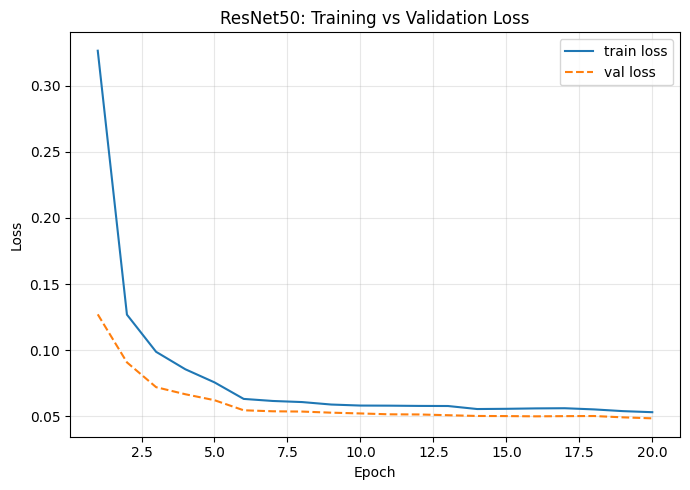

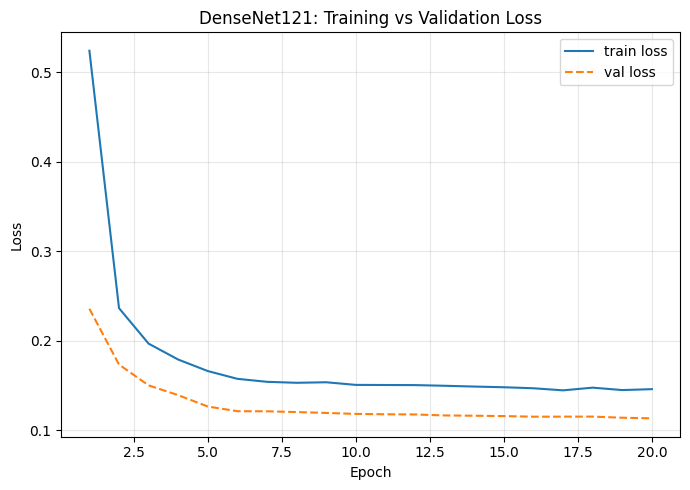

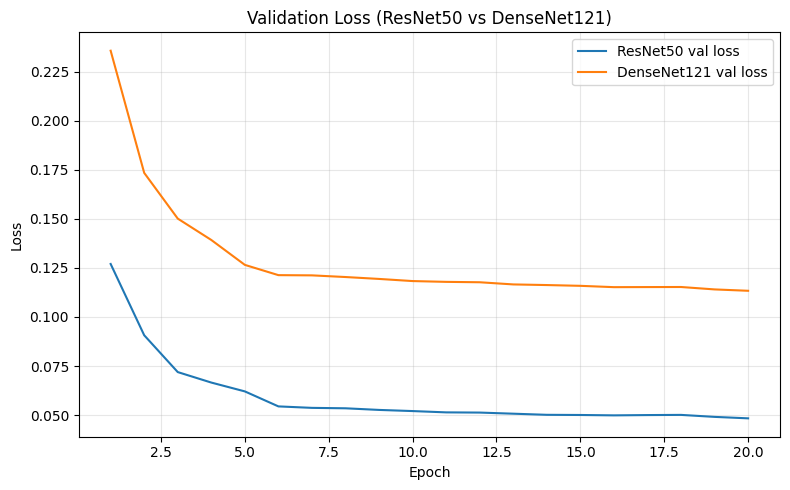

Saved: q16_epoch_losses_resnet.csv, q16_epoch_losses_densenet.csv, q16_epoch_losses_combined.csv
Saved figures: q16_resnet_loss.png, q16_densenet_loss.png, q16_val_loss_overlay.png


In [ ]:
# ===== Q16: Record & export per-epoch losses for ResNet50 and DenseNet121 =====
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1) Load the logs created in Q15 by CSVLogger
assert os.path.exists("resnet_log.csv"), "resnet_log.csv not found. Re-run Q15 training."
assert os.path.exists("densenet_log.csv"), "densenet_log.csv not found. Re-run Q15 training."

res = pd.read_csv("resnet_log.csv")
dns = pd.read_csv("densenet_log.csv")

# 2) Keras CSVLogger includes 'epoch' and metric columns. We only need train/val loss (plus epoch).
#    Some Keras versions order columns slightly differently; we select by *name* to be safe.
needed_cols = [c for c in ["epoch", "loss", "val_loss"] if c in res.columns]
res = res[needed_cols].copy()
dns = dns[needed_cols].copy()

# Make epochs 1-indexed if they start at 0 (common with CSVLogger)
if "epoch" in res and res["epoch"].min() == 0:
    res["epoch"] = res["epoch"] + 1
if "epoch" in dns and dns["epoch"].min() == 0:
    dns["epoch"] = dns["epoch"] + 1

res["model"] = "ResNet50"
dns["model"] = "DenseNet121"

# 3) Save clean per-epoch CSVs for your report archive
res.to_csv("q16_epoch_losses_resnet.csv", index=False)
dns.to_csv("q16_epoch_losses_densenet.csv", index=False)

# Also a combined file for easier plotting/inspection
combined = pd.concat([res, dns], ignore_index=True)
combined.to_csv("q16_epoch_losses_combined.csv", index=False)

# 4) Plot training vs validation loss for each model (separate figures and an overlaid one)
def plot_losses(df, title, fname):
    plt.figure(figsize=(7,5))
    plt.plot(df["epoch"], df["loss"], label="train loss")
    plt.plot(df["epoch"], df["val_loss"], "--", label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

plot_losses(res, "ResNet50: Training vs Validation Loss", "q16_resnet_loss.png")
plot_losses(dns, "DenseNet121: Training vs Validation Loss", "q16_densenet_loss.png")

# Overlaid plot
plt.figure(figsize=(8,5))
plt.plot(res["epoch"], res["val_loss"], label="ResNet50 val loss")
plt.plot(dns["epoch"], dns["val_loss"], label="DenseNet121 val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Validation Loss (ResNet50 vs DenseNet121)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("q16_val_loss_overlay.png", dpi=150)
plt.show()

print("Saved: q16_epoch_losses_resnet.csv, q16_epoch_losses_densenet.csv, q16_epoch_losses_combined.csv")
print("Saved figures: q16_resnet_loss.png, q16_densenet_loss.png, q16_val_loss_overlay.png")


In [ ]:
# ===== Q17: Evaluate on test set and record metrics =====
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# Assumes you still have:
#   resnet_model, densenet_model  (trained in Q15)
#   resnet_test, dns_test         (tf.data Datasets built in Q14)
# And NUM_CLASSES from earlier:
try:
    NUM_CLASSES
except NameError:
    NUM_CLASSES = 10
CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]

def evaluate_and_save(model, test_ds, arch_name, class_names=None):
    """Evaluate a trained Keras model on a tf.data test dataset whose labels are one-hot,
    then save metrics & artifacts for the report."""
    y_true, y_pred = [], []

    for xb, yb in test_ds:
        # Predict probabilities -> class indices
        probs = model.predict(xb, verbose=0)                  # Keras Model.predict :contentReference[oaicite:2]{index=2}
        y_pred.extend(np.argmax(probs, axis=1))

        # Ground truth may be one-hot; convert to indices
        yb_np = yb.numpy()
        if yb_np.ndim > 1:
            y_true.extend(np.argmax(yb_np, axis=1))
        else:
            y_true.extend(yb_np)

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)

    # --- Metrics (official sklearn metrics) ---
    acc        = accuracy_score(y_true, y_pred)                                   # :contentReference[oaicite:3]{index=3}
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0) # :contentReference[oaicite:4]{index=4}
    rec_macro  = recall_score(y_true, y_pred, average="macro",  zero_division=0)   # :contentReference[oaicite:5]{index=5}

    # Optional (for completeness): micro averages
    prec_micro = precision_score(y_true, y_pred, average="micro", zero_division=0) # ≈ accuracy in multi-class :contentReference[oaicite:6]{index=6}
    rec_micro  = recall_score(y_true, y_pred, average="micro",  zero_division=0)

    # Confusion matrix (counts) + normalized (by true class)
    cm = confusion_matrix(y_true, y_pred)                                         # :contentReference[oaicite:7]{index=7}
    cm_df = pd.DataFrame(cm,
                         index=class_names if class_names else None,
                         columns=class_names if class_names else None)
    cm_df.to_csv(f"{arch_name}_confusion_matrix.csv", index=class_names is not None)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm_df = pd.DataFrame(cm_norm,
                              index=class_names if class_names else None,
                              columns=class_names if class_names else None)
    cm_norm_df.to_csv(f"{arch_name}_confusion_matrix_normalized.csv", index=class_names is not None)

    # Full per-class report
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)  # :contentReference[oaicite:8]{index=8}
    pd.DataFrame(report).transpose().to_csv(f"{arch_name}_classification_report.csv")

    # Summary metrics text (easy to paste into report)
    with open(f"{arch_name}_metrics.txt", "w") as f:
        f.write(
            f"test_accuracy={acc:.6f}\n"
            f"precision_macro={prec_macro:.6f}\n"
            f"recall_macro={rec_macro:.6f}\n"
            f"precision_micro={prec_micro:.6f}\n"
            f"recall_micro={rec_micro:.6f}\n"
        )

    print(f"[{arch_name}] "
          f"acc={acc:.4f} | P_macro={prec_macro:.4f} | R_macro={rec_macro:.4f} "
          f"| P_micro={prec_micro:.4f} | R_micro={rec_micro:.4f}")

    return {
        "Model": arch_name,
        "Accuracy": acc,
        "Precision_macro": prec_macro,
        "Recall_macro": rec_macro,
        "Precision_micro": prec_micro,
        "Recall_micro": rec_micro
    }

# ---- Evaluate both fine-tuned models on the SAME test split ----
res_metrics = evaluate_and_save(resnet_model,   resnet_test,   "resnet",   class_names=CLASS_NAMES)
dns_metrics = evaluate_and_save(densenet_model, dns_test,      "densenet", class_names=CLASS_NAMES)

# Combined summary table (handy for Q18)
summary_q17 = pd.DataFrame([res_metrics, dns_metrics])
summary_q17.to_csv("q17_test_metrics_summary.csv", index=False)
print("\nSaved: resnet_* and densenet_* metric files + q17_test_metrics_summary.csv")
summary_q17


[resnet] acc=0.9840 | P_macro=0.9838 | R_macro=0.9838 | P_micro=0.9840 | R_micro=0.9840
[densenet] acc=0.9672 | P_macro=0.9666 | R_macro=0.9667 | P_micro=0.9672 | R_micro=0.9672

Saved: resnet_* and densenet_* metric files + q17_test_metrics_summary.csv


,Model,Accuracy,Precision_macro,Recall_macro,Precision_micro,Recall_micro
0,resnet,0.984000,0.983824,0.983822,0.984000,0.984000
1,densenet,0.967238,0.966626,0.966748,0.967238,0.967238



=== RESNET — Classification Report ===
              precision    recall  f1-score   support

           0     0.9971    0.9952    0.9961      1035
           1     0.9907    0.9958    0.9932      1182
           2     0.9795    0.9590    0.9691      1048
           3     0.9776    0.9776    0.9776      1071
           4     0.9854    0.9873    0.9863      1024
           5     0.9707    0.9789    0.9748       947
           6     0.9864    0.9864    0.9864      1031
           7     0.9845    0.9890    0.9868      1094
           8     0.9863    0.9863    0.9863      1024
           9     0.9799    0.9828    0.9813      1044

    accuracy                         0.9840     10500
   macro avg     0.9838    0.9838    0.9838     10500
weighted avg     0.9840    0.9840    0.9840     10500



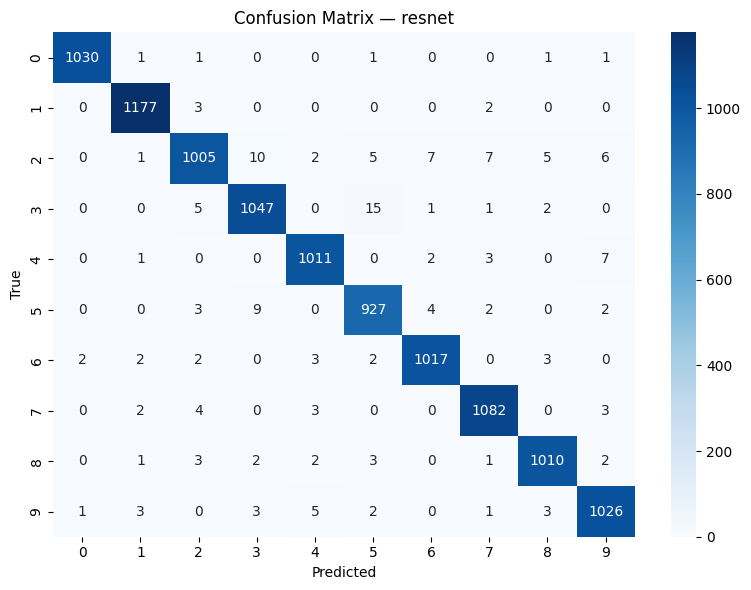

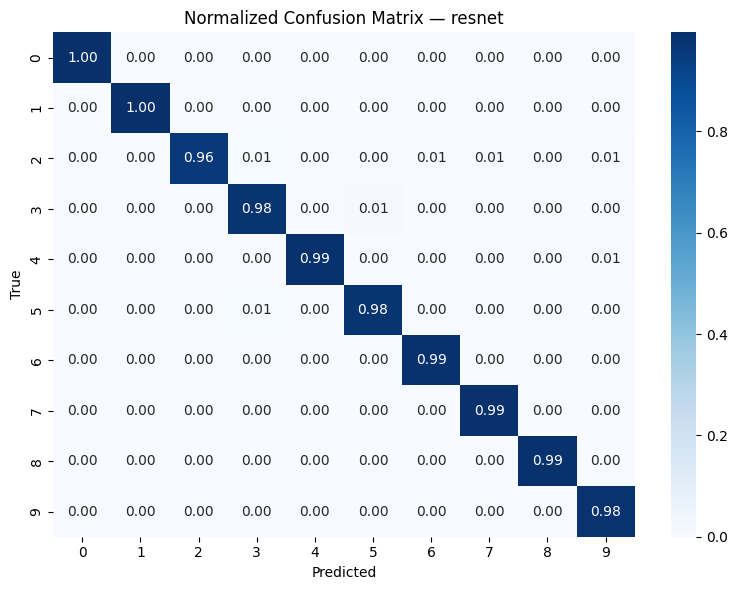


=== DENSENET — Classification Report ===
              precision    recall  f1-score   support

           0     0.9810    0.9952    0.9880      1035
           1     0.9899    0.9924    0.9911      1182
           2     0.9670    0.9237    0.9449      1048
           3     0.9431    0.9440    0.9435      1071
           4     0.9699    0.9766    0.9732      1024
           5     0.9156    0.9398    0.9276       947
           6     0.9776    0.9758    0.9767      1031
           7     0.9745    0.9762    0.9753      1094
           8     0.9698    0.9727    0.9712      1024
           9     0.9778    0.9713    0.9745      1044

    accuracy                         0.9672     10500
   macro avg     0.9666    0.9667    0.9666     10500
weighted avg     0.9673    0.9672    0.9672     10500



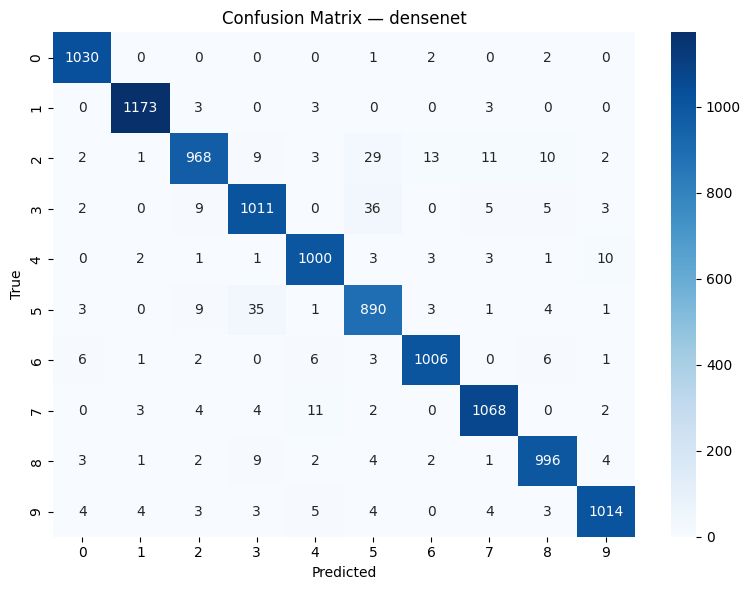

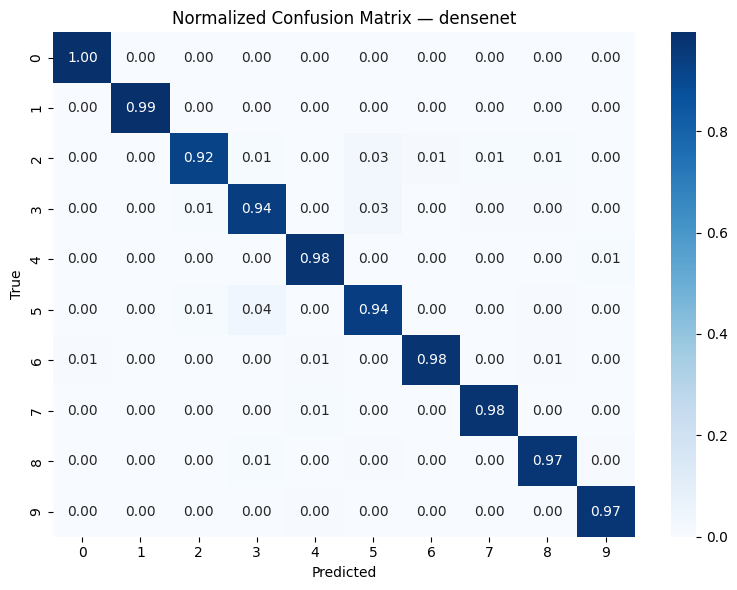

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix  # docs: sklearn.metrics.classification_report, confusion_matrix

# Assumes these exist from Q14–Q15:
#   resnet_model, densenet_model
#   resnet_test, dns_test
NUM_CLASSES = 10
CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]

def report_and_plot(model, test_ds, arch_name, class_names=None):
    """Print text classification report and save/show confusion-matrix heatmaps."""
    y_true, y_pred = [], []
    for xb, yb in test_ds:
        probs = model.predict(xb, verbose=0)  # Keras Model.predict
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(yb.numpy(), axis=1))  # labels are one-hot in your pipeline

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)

    # ---- Text report (includes per-class precision/recall/F1 + overall accuracy) ----
    print(f"\n=== {arch_name.upper()} — Classification Report ===")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                digits=4,
                                zero_division=0))

    # ---- Confusion matrix: raw counts ----
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {arch_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'{arch_name}_cm_counts.png', dpi=150)
    plt.show()

    # ---- Confusion matrix: normalized by true class ----
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Normalized Confusion Matrix — {arch_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'{arch_name}_cm_normalized.png', dpi=150)
    plt.show()

    # Save the raw numbers too (good for your appendix)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(f"{arch_name}_confusion_matrix.csv")
    pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(f"{arch_name}_confusion_matrix_normalized.csv")

# Run for both fine-tuned models
report_and_plot(resnet_model,   resnet_test,   "resnet",   CLASS_NAMES)
report_and_plot(densenet_model, dns_test,      "densenet", CLASS_NAMES)


Saved q18_comparison_table.csv


,Model,Params (M),Test Acc,Precision (macro),Recall (macro),F1 (macro)
0,Custom CNN,0.42,0.9914,0.9915,0.9913,0.9914
1,ResNet50-FT,23.61,0.9840,0.9838,0.9838,0.9838
2,DenseNet121-FT,7.05,0.9672,0.9666,0.9667,0.9666


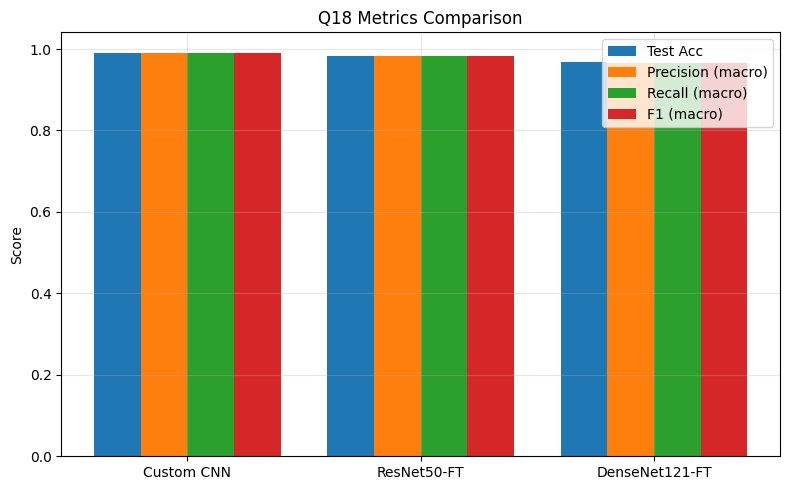

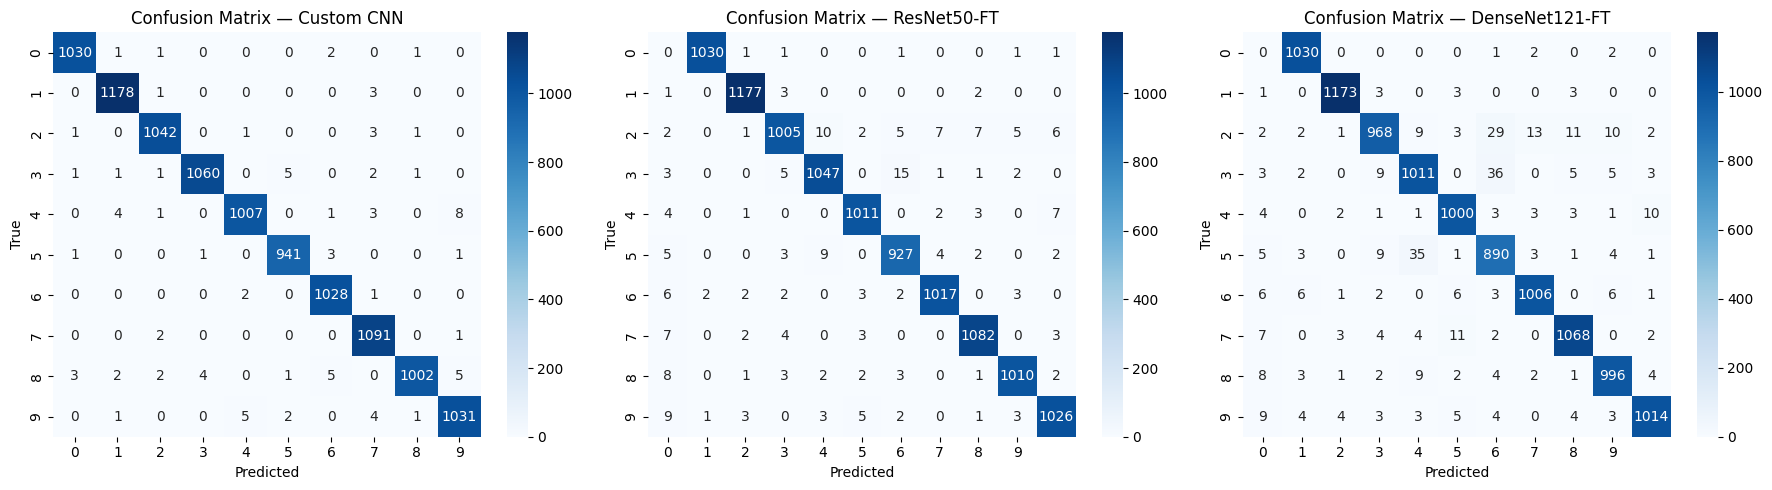

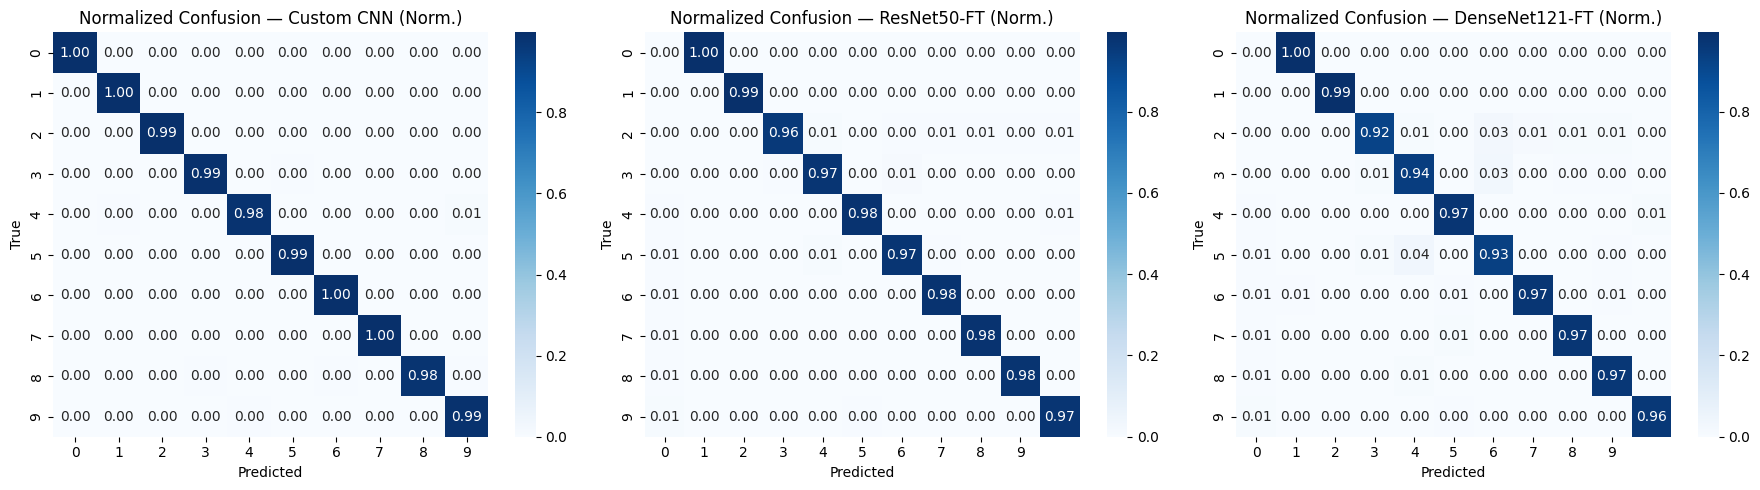

Saved: q18_cm_triptych_counts.png, q18_cm_triptych_normalized.png


In [ ]:
# === Add macro-F1 to the Q18 comparison (robust: read from report or compute) ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Helper: read macro-F1 from a classification report CSV if it exists
def read_macro_f1_from_report(path):
    if os.path.exists(path):
        df = pd.read_csv(path, index_col=0)
        if "macro avg" in df.index and "f1-score" in df.columns:
            return float(df.loc["macro avg", "f1-score"])
    return None

# Helper: compute macro-F1 by running predictions on a tf.data test dataset
def compute_macro_f1_from_model(model, test_ds, one_hot=True):
    y_true, y_pred = [], []
    for xb, yb in test_ds:
        probs = model.predict(xb, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        if one_hot:
            y_true.extend(np.argmax(yb.numpy(), axis=1))
        else:
            y_true.extend(yb.numpy())
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

# 1) Load existing Q18 table (without F1)
cmp = pd.read_csv("q18_comparison_table.csv")

# 2) Get macro-F1 for each model
# -- Custom CNN
custom_f1 = read_macro_f1_from_report("custom_classification_report.csv")
if custom_f1 is None:
    # If no report CSV, try to compute using a model still in memory
    try:
        custom_f1 = compute_macro_f1_from_model(final_model,  # or custom_model if that's your variable name
                                                [(X_test, y_test)], one_hot=True)
    except NameError:
        # As a last resort, rebuild & evaluate quickly (same split)
        try:
            from tensorflow import keras
            custom_tmp = compile_model('adam', 1e-3)
            custom_tmp.fit(X_train, y_train, validation_data=(X_val, y_val),
                           epochs=1, batch_size=32, verbose=0)
            custom_f1 = compute_macro_f1_from_model(custom_tmp, [(X_test, y_test)], one_hot=True)
        except Exception:
            custom_f1 = np.nan

# -- ResNet50-FT
resnet_f1 = read_macro_f1_from_report("resnet_classification_report.csv")
if resnet_f1 is None:
    resnet_f1 = compute_macro_f1_from_model(resnet_model, resnet_test, one_hot=True)

# -- DenseNet121-FT
densenet_f1 = read_macro_f1_from_report("densenet_classification_report.csv")
if densenet_f1 is None:
    densenet_f1 = compute_macro_f1_from_model(densenet_model, dns_test, one_hot=True)

# 3) Patch the table
cmp.loc[cmp["Model"] == "Custom CNN",     "F1 (macro)"] = custom_f1
cmp.loc[cmp["Model"] == "ResNet50-FT",    "F1 (macro)"] = resnet_f1
cmp.loc[cmp["Model"] == "DenseNet121-FT", "F1 (macro)"] = densenet_f1

# Reorder columns to include F1
cols = ["Model", "Params (M)", "Test Acc", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
cmp = cmp[cols]

# Save and display
cmp.to_csv("q18_comparison_table.csv", index=False)
print("Saved q18_comparison_table.csv")
display(cmp.style.format({
    "Test Acc":"{:.4f}",
    "Precision (macro)":"{:.4f}",
    "Recall (macro)":"{:.4f}",
    "F1 (macro)":"{:.4f}",
    "Params (M)":"{:.2f}"
}).set_caption("Q18: Custom vs Fine-tuned Models"))

# 4) Update grouped bar chart to include F1
plt.figure(figsize=(8,5))
metrics = ["Test Acc", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
x = np.arange(len(cmp))
w = 0.2
for i, m in enumerate(metrics):
    plt.bar(x + i*w, cmp[m].values, width=w, label=m)
plt.xticks(x + 1.5*w, cmp["Model"].values)
plt.ylabel("Score")
plt.title("Q18 Metrics Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q18_metrics_bar_with_f1.png", dpi=150)
plt.show()

# === Q18: Side-by-side confusion matrices for Custom, ResNet50-FT, DenseNet121-FT ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABELS = [str(i) for i in range(10)]

def _load_cm_or_compute(csv_path, model=None, test_data=None, one_hot=True):
    """
    Returns a raw (counts) confusion matrix.
    If csv_path exists, loads it; otherwise computes from model+test_data and saves it.
    - For tf.data datasets, pass test_data = test_ds (y is one-hot in your pipeline).
    - For numpy arrays, pass test_data = (X_test, y_test).
    """
    if os.path.exists(csv_path):
        return pd.read_csv(csv_path, index_col=None).values

    if model is None or test_data is None:
        # If we can't compute, return None so caller can decide what to do.
        return None

    # Compute from model predictions
    if isinstance(test_data, tuple):
        X_test, y_test = test_data
        probs = model.predict(X_test, verbose=0)
        y_pred = np.argmax(probs, axis=1)
        y_true = np.argmax(y_test, axis=1) if (one_hot and y_test.ndim > 1) else y_test
    else:
        # tf.data pipeline
        y_true, y_pred = [], []
        for xb, yb in test_data:
            probs = model.predict(xb, verbose=0)
            y_pred.extend(np.argmax(probs, axis=1))
            y_true.extend(np.argmax(yb.numpy(), axis=1) if one_hot else yb.numpy())
        y_true = np.array(y_true, dtype=int)
        y_pred = np.array(y_pred, dtype=int)

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm).to_csv(csv_path, index=False)
    return cm

def _norm_by_row(cm):
    return cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 1) Load or compute raw CMs
cm_custom   = _load_cm_or_compute("custom_confusion_matrix.csv",
                                  model=globals().get("final_model", None) or globals().get("custom_model", None),
                                  test_data=(globals().get("X_test", None), globals().get("y_test", None))
                                  if "X_test" in globals() and "y_test" in globals() else None)

cm_resnet   = _load_cm_or_compute("resnet_confusion_matrix.csv",
                                  model=globals().get("resnet_model", None),
                                  test_data=globals().get("resnet_test", None))

cm_densenet = _load_cm_or_compute("densenet_confusion_matrix.csv",
                                  model=globals().get("densenet_model", None),
                                  test_data=globals().get("dns_test", None))

# Guard: if any CM is still None, raise a friendly error
missing = [name for name, cm in [("Custom CNN", cm_custom), ("ResNet50-FT", cm_resnet), ("DenseNet121-FT", cm_densenet)] if cm is None]
if missing:
    raise RuntimeError(f"Missing confusion matrices for: {', '.join(missing)}. "
                       "Ensure Q17 was run (which saves the CSVs), or keep the models in memory to compute them.")

# 2) Plot counts side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, title in zip(
    axes,
    [cm_custom, cm_resnet, cm_densenet],
    ["Custom CNN", "ResNet50-FT", "DenseNet121-FT"]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("q18_cm_triptych_counts.png", dpi=150)
plt.show()

# 3) Plot normalized (per-class) side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, title in zip(
    axes,
    [_norm_by_row(cm_custom), _norm_by_row(cm_resnet), _norm_by_row(cm_densenet)],
    ["Custom CNN (Norm.)", "ResNet50-FT (Norm.)", "DenseNet121-FT (Norm.)"]
):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"Normalized Confusion — {title}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("q18_cm_triptych_normalized.png", dpi=150)
plt.show()

print("Saved: q18_cm_triptych_counts.png, q18_cm_triptych_normalized.png")

